In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(0)
n=200
X=np.linspace(-3, 3, n).reshape(-1, 1)
y=2*X.ravel() - 0.3 + 0.7* np.random.random(n)

In [4]:
#Batch Gradient Descent
def batch_gd(X, y, lr=0.05, epochs=200):
    w, b=0.0, 0.0
    losses=[]
    for _ in range(epochs):
        preds=w*X.ravel() +b
        err =preds-y
        loss=(err**2).mean()/2
        losses.append(loss)
        dw=(X.ravel()* err).mean()
        db=err.mean()
        w-=lr*dw
        b-=lr*db
    return w, b, losses

In [5]:
#Stochastic Gradient Descent
def sgd(X, y,lr=0.05, epochs=200):
    w, b=0.0,0.0
    losses=[]
    n=len(y)
    for _ in range(epochs):
        indices=np.random.permutation(n)
        epoch_loss=0;
        for i in indices:
            xi, yi=X.ravel()[i], y[i]
            pred=w*xi+b
            err=pred-yi
            loss=(err**2)/2
            epoch_loss+=loss
            dw=xi*err
            db=err
            w-=lr*dw
            b-=lr*db
        losses.append(epoch_loss/n)
    return w, b, losses

In [8]:
#Mini Batch Gradient Descent
def minibatch_gd(X, y, lr=0.05, epochs=200, batch_size=16):
    w, b=0.0,0.0
    losses=[]
    n=len(y)
    for _ in range(epochs):
        indices=np.random.permutation(n)
        epoch_loss=0
        for start in range(0, n, batch_size):
            batch_idx=indices[start:start+ batch_size]
            xb, yb=X.ravel()[batch_idx], y[batch_idx]
            preds=w*xb+b
            err=preds - yb
            loss=(err**2).mean()/2
            epoch_loss+= loss*len(batch_idx)
            dw=(xb * err).mean()
            db=err.mean()
            w -= lr*dw
            b -= lr*db
        losses.append(epoch_loss/n)
    return w, b, losses

In [9]:
w_b, b_b, loss_b=batch_gd(X, y)
w_s, b_s, loss_s=sgd(X, y)
w_m, b_m, loss_m=minibatch_gd(X, y)

print(f"True params:  w=2.0000, b=-0.3000")
print(f"Batch:        w={w_b:.4f}, b={b_b:.4f}")
print(f"SGD:          w={w_s:.4f}, b={b_s:.4f}")
print(f"MiniBatch:    w={w_m:.4f}, b={b_m:.4f}")

try:
    from sklearn.linear_model import LinearRegression
    sk=LinearRegression().fit(X, y)
    print(f"sklearn:    w={sk.coef_[0]:.4f}, b={sk.intercept_:.4f}")
except ImportError:
    pass

True params:  w=2.0000, b=-0.3000
Batch:        w=1.9968, b=0.0503
SGD:          w=1.9709, b=0.0840
MiniBatch:    w=1.9942, b=0.0559
sklearn:    w=1.9968, b=0.0503


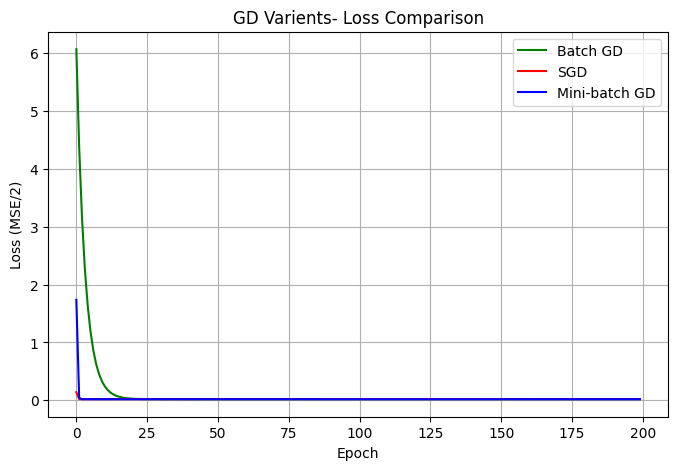

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(loss_b, label="Batch GD", color="green")
plt.plot(loss_s, label="SGD", color="red")
plt.plot(loss_m, label="Mini-batch GD", color="blue")
plt.title("GD Varients- Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE/2)")
plt.legend()
plt.grid(True)
plt.show()

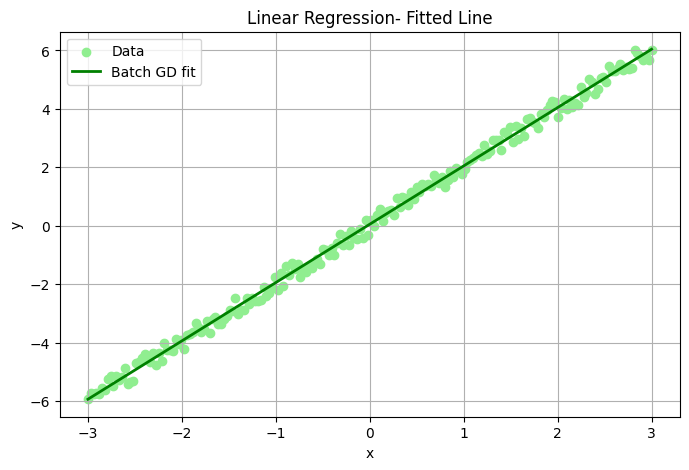

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="lightgreen", label="Data")
idx=np.argsort(X.ravel())
plt.plot(X[idx], (w_b * X + b_b)[idx], color="green", linewidth=2, label="Batch GD fit")
plt.title("Linear Regression- Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

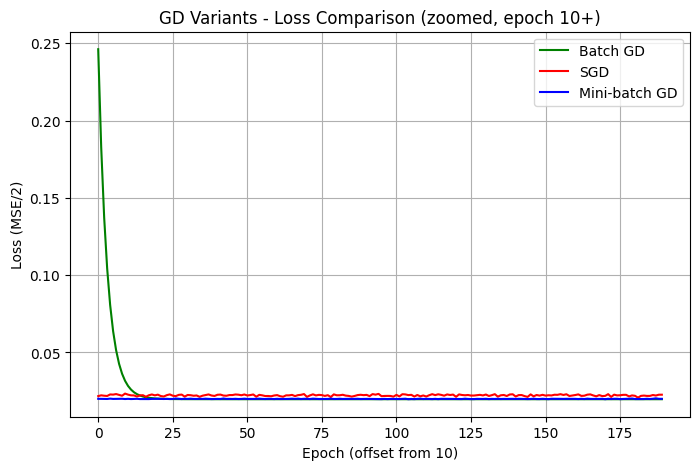

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(loss_b[10:], label="Batch GD", color="green")
plt.plot(loss_s[10:], label="SGD", color="red")
plt.plot(loss_m[10:], label="Mini-batch GD", color="blue")
plt.title("GD Variants - Loss Comparison (zoomed, epoch 10+)")
plt.xlabel("Epoch (offset from 10)")
plt.ylabel("Loss (MSE/2)")
plt.legend()
plt.grid(True)
plt.show()

lr=0.001 (too small): final w=0.9085, b=0.0091
lr=0.05 (good): final w=1.9968, b=0.0503
lr=0.5 (too large): final w=1.9968, b=0.0503


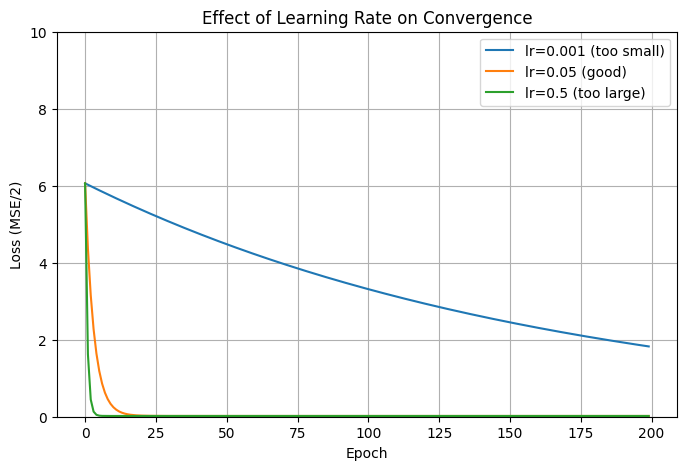

In [14]:
lrs = {"lr=0.001 (too small)": 0.001, "lr=0.05 (good)": 0.05, "lr=0.5 (too large)": 0.5}
results = {}

for label, lr_val in lrs.items():
    w, b, losses = batch_gd(X, y, lr=lr_val, epochs=200)
    results[label] = losses
    print(f"{label}: final w={w:.4f}, b={b:.4f}")

plt.figure(figsize=(8, 5))
for label, losses in results.items():
    plt.plot(losses, label=label)
plt.title("Effect of Learning Rate on Convergence")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE/2)")
plt.legend()
plt.grid(True)
plt.ylim(0, 10)   # cap y-axis in case lr=0.5 diverges to huge values
plt.show()

In [15]:
for lr_val in [0.05, 0.5, 1.5, 2.5]:
    w, b, losses = batch_gd(X, y, lr=lr_val, epochs=50)
    print(f"lr={lr_val}: final loss={losses[-1]:.6f}, w={w:.4f}, b={b:.4f}")
    print(f"  last 5 losses: {losses[-5:]}")

lr=0.05: final loss=0.019742, w=1.9963, b=0.0464
  last 5 losses: [np.float64(0.019748041382032264), np.float64(0.019746180688135096), np.float64(0.019744618384109913), np.float64(0.019743292617641788), np.float64(0.01974215674160444)]
lr=0.5: final loss=0.019733, w=1.9968, b=0.0503
  last 5 losses: [np.float64(0.019733241112421723), np.float64(0.019733241112421727), np.float64(0.019733241112421727), np.float64(0.019733241112421716), np.float64(0.019733241112421727)]
lr=1.5: final loss=4428036544505210479849873491264707338369853214177624064.000000, w=-6060834426705941771365384192.0000, b=151603748434.9714
  last 5 losses: [np.float64(1.7744332342509868e+50), np.float64(2.2302191795461023e+51), np.float64(2.8030795934200546e+52), np.float64(3.523086555397243e+53), np.float64(4.4280365445052105e+54)]
lr=2.5: final loss=865622760637961823175107725619087955288220325627397380975674382648081240146575360.000000, w=-157169352559629488019121291967013467455488.0000, b=5991505567365484095995904.0